# README
1. AUSPEX is a BBN instrumnet control package. 
2. We are using SRS SR865 lockin + RenSci piezo stage. Both connected via ethernet with static IP addresses
3. AUSPEX has a number of 'import visa' scattered across the source code; needs to be updated to 'import pyvisa as visa'. Best to push these changes or fork the repo and have a local copy.

In [ ]:
%load_ext autoreload
%autoreload 2
from auspex.instruments import SR865
from rensci import RenSciDriver
import numpy as np

In [2]:
PIEZO_HOST = "172.31.255.99"
PIEZO_PORT = 6002

In [3]:
lockin = SR865()
lockin.connect('TCPIP0::172.31.255.252')

print(f"Connected to {lockin.name} \n\n X= {lockin.x}, Y = {lockin.y}")

xyz = RenSciDriver(PIEZO_HOST, PIEZO_PORT)
xyz.connect()

Connected to SR865 Lockin Amplifier 

 X= 0.013460067101, Y = -7.4246847362e-05
Connected to 172.31.255.99:6002


In [65]:
xyz.goPosition(1, -4.4)
xyz.goPosition(2, -1.15)
xyz.goPosition(3, -3.23)
r=[]
# for i in range(100):
#     xyz.goStepsForward(1, steps=10)
#     r.append(lockin.r)

In [9]:
import matplotlib.pyplot as plt

In [6]:
xyz.goPosition(1, -4)


{'id': '178', 'jsonrpc': '2.0', 'result': True}

In [7]:
r=[]
x = []
for i in range(600):
    xyz.goStepsForward(1, steps=10)
    r.append(lockin.r)
    x.append(xyz.getPosition(1))

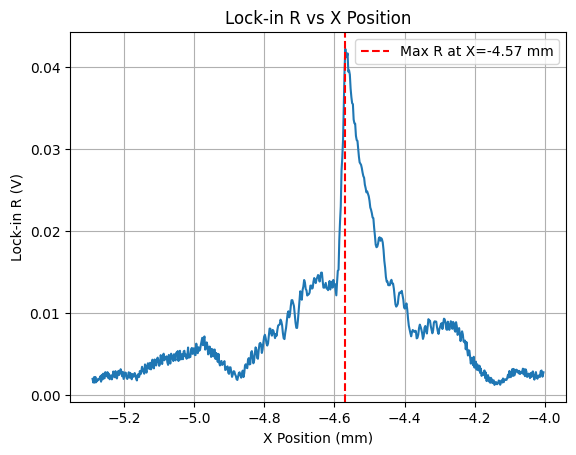

In [18]:
r = np.array(r)
x = np.array(x)
np.argmax(r)

plt.plot(x, r)
plt.xlabel("X Position (mm)")
plt.ylabel("Lock-in R (V)")
plt.title("Lock-in R vs X Position")
plt.axvline(x[np.argmax(r)], color='r', linestyle='--', label=f'Max R at X={x[np.argmax(r)]:.2f} mm')
plt.grid()
plt.legend()

In [19]:
xyz.goPosition(1, x[np.argmax(r)]  )

{'id': '24921', 'jsonrpc': '2.0', 'result': True}

In [28]:
xyz.goPosition(2, -1.15 )
nsteps = 2000
stepsize = 10
y = []
r= []
xyz.goStepsReverse(2, int(nsteps/2))
for i in range(nsteps):
    r.append(lockin.r)
    y.append(xyz.getPosition(2))
    xyz.goStepsForward(2, stepsize)

In [16]:
r[263]

np.float64(0.042213559151)

/var/folders/62/mcqwstd50y96l1tfpcvcwz6w0000gn/T/ipykernel_32257/2211636307.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


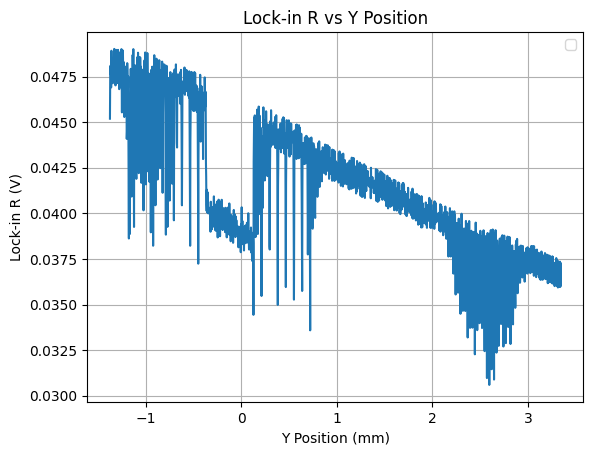

In [29]:
r = np.array(r)
y = np.array(y)
# np.argmax(r)

plt.plot(y, r)
plt.xlabel("Y Position (mm)")
plt.ylabel("Lock-in R (V)")
plt.title("Lock-in R vs Y Position")
# plt.axvline(y[np.argmax(r)], color='r', linestyle='--', label=f'Max R at Y={y   [np.argmax(r)]:.2f} mm')
plt.grid()
plt.legend()

In [27]:
np.mean(np.diff(y))*1e3

np.float64(4.828772024525778)

In [73]:
def refocus(channel=1, nsteps=15, stepsize=10):
    x=[]
    r=[]
    xyz.goStepsReverse(channel, int(nsteps/2)*stepsize)
    for i in range(nsteps):
        r.append(lockin.r)
        x.append(xyz.getPosition(channel))
        xyz.goStepsForward(channel, stepsize)
    r = np.array(r)
    x = np.array(x)
    return x[np.argmax(r)], x,r
    

# xyz.goPosition(1, refocus(channel=1)[0])


In [71]:
x0, x, r = refocus(1)

In [68]:
xyz.goPosition(1, x0)

{'id': '228266', 'jsonrpc': '2.0', 'result': True}

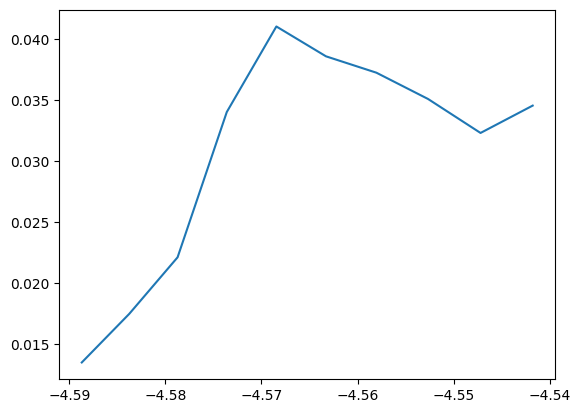

In [72]:
plt.plot(x,r)

In [57]:
xyz.goPosition(1, x0)

{'id': '226381', 'jsonrpc': '2.0', 'result': True}

In [41]:
np.mean(np.diff(refocus(channel=1)[1]))

np.float64(-0.009523392657737209)

In [74]:
xyz.goPosition(2, -1.15 )
nsteps = 200
stepsize = 20
y = []
r= []
x0=[]
xyz.goStepsReverse(2, int(nsteps/2)*stepsize)
for i in range(nsteps):
    r.append(lockin.r)
    y.append(xyz.getPosition(2))
    xyz.goStepsForward(2, stepsize)
    
    x0.append( refocus(channel=1)[0] )
    xyz.goPosition(1, x0[-1])



KeyboardInterrupt: 

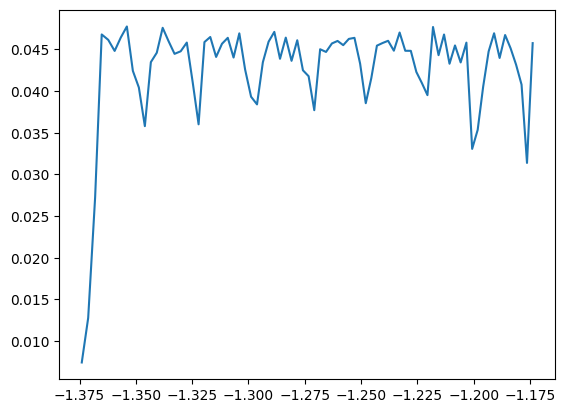

In [43]:
plt.plot(y, r)

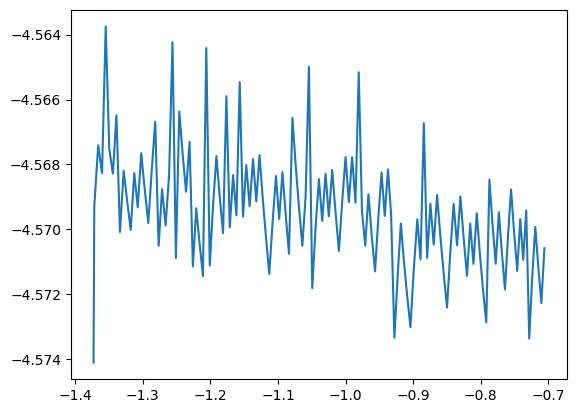

In [80]:
plt.plot(y[:-1],x0)

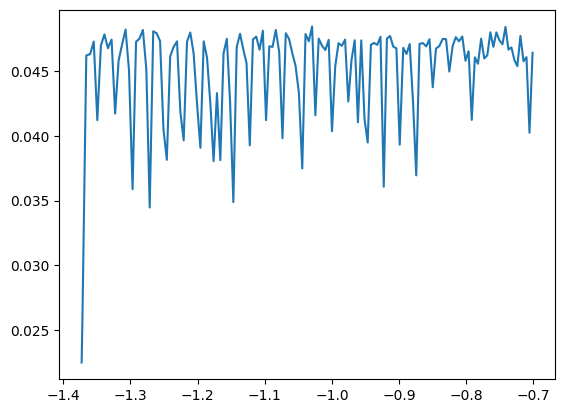

In [81]:
plt.plot(y, r)

In [83]:
np.mean(np.diff(y))*1e3

np.float64(4.86577745693015)